In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.colors as mcolors
import json
import numpy as np
from matplotlib.patches import Patch
import json
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.style.use("~/PhD/subdom_asym/code_subdom_asym/MATPLOTLIB_RCPARAMS.sty")

In [2]:
# import json files 
with open('sxsv3/tref_tm100_copr/mf_data.json') as json_file:
    data = json.load(json_file)

for key, value in data.items():
        locals()[key] = np.array(value)

mf_minus_dict = dict(zip(map(tuple, mode_list_m_pos.tolist()), magic_factors_minus.T))
mf_plus_dict = dict(zip(map(tuple, mode_list_m_pos.tolist()), magic_factors_plus.T)) 


with open('PN/pn_sxs_copr_interp/mf_data.json') as json_file:
    data = json.load(json_file)

for key, value in data.items():
        locals()[key] = np.array(value)

mf_from_omega_a_dict = dict(zip(map(tuple, mode_list_m_pos.tolist()), magic_factors_minus.T))
mf_from_omega_s_dict = dict(zip(map(tuple, mode_list_m_pos.tolist()), magic_factors_plus.T))

In [3]:
def add_half_violin(ax, data_dict, keys, color, side='left', positions=None, width=0.9, alpha=0.5, showmedians=True):
    data = [data_dict[key] for key in keys]
    vp = ax.violinplot(data, showmeans=False, showextrema=False, showmedians=showmedians,
                       vert=False, widths=width, positions=positions, points=1000)
    for body in vp['bodies']:
        path = body.get_paths()[0]
        vertices = path.vertices
        y = vertices[:, 1]
        center = np.mean(y)
        if side == 'left':
            y_new = np.where(y > center, center, y)
        else:
            y_new = np.where(y < center, center, y)
        vertices[:, 1] = y_new
        body.set_facecolor(color)
        body.set_alpha(alpha)

        # Median-Linie einfärben
    if 'cmedians' in vp:
        vp['cmedians'].set_color(color)
        vp['cmedians'].set_linewidth(2)
    return vp

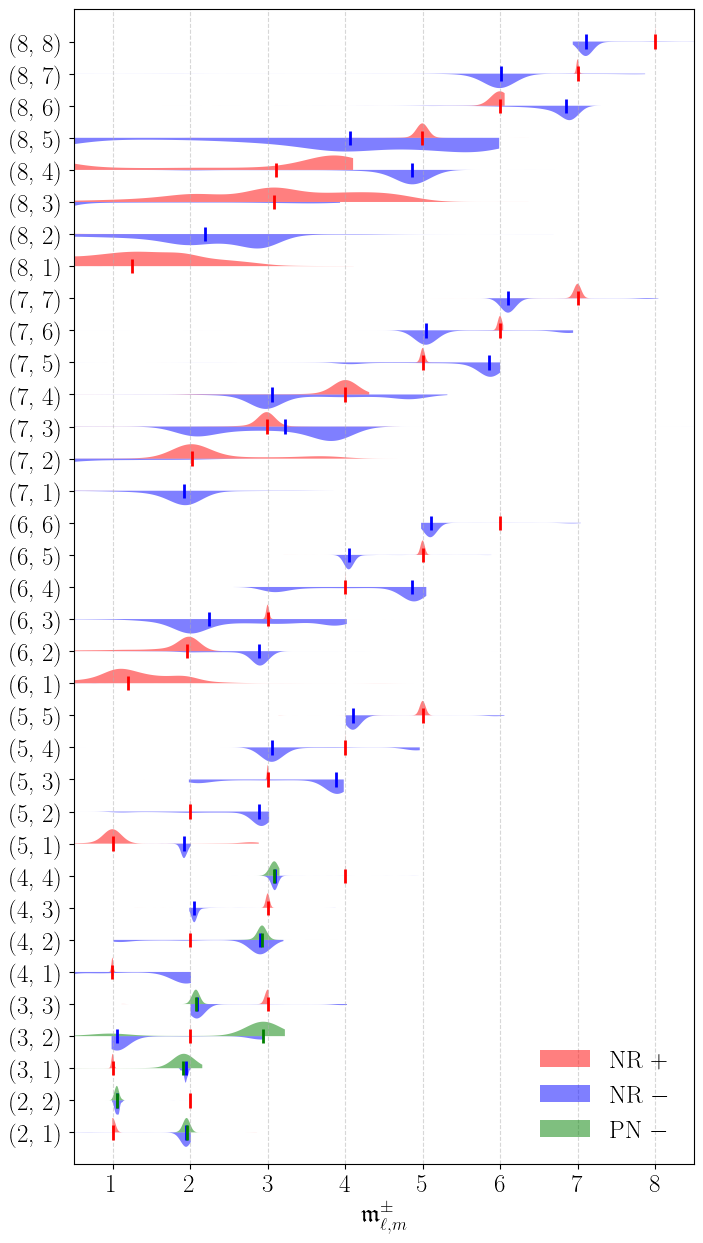

In [ ]:
fig, ax1 = plt.subplots(figsize=(8,15))

# Keys
keys_nr = [key for key in mf_minus_dict.keys() if key <= (8,8) and key[1] != 0]
keys_pn = [(2,2), (2,1), (3,3), (3,2), (3,1), (4,4), (4,2)]

# y-positions
positions_nr = np.arange(1, len(keys_nr)+1)
positions_pn = [positions_nr[keys_nr.index(key)] if key in keys_nr else len(keys_nr)+1 for key in keys_pn]

# Plots
add_half_violin(ax1, mf_minus_dict, keys_nr, 'blue', side='left', positions=positions_nr)
add_half_violin(ax1, mf_from_omega_a_dict, keys_pn, 'green', side='right', positions=positions_pn)
add_half_violin(ax1, mf_plus_dict, keys_nr, 'red', side='right', positions=positions_nr)

# Achsen
all_positions = list(positions_nr) + [pos for pos in positions_pn if pos > len(keys_nr)]
ax1.set_yticks(all_positions)
ax1.set_yticklabels([str(keys_nr[i-1]) if i <= len(keys_nr) else str(keys_pn[i-len(keys_nr)-1])
                     for i in all_positions])
ax1.set_xlabel(r'$\mathfrak{m}^\pm_{\ell,m}$')
ax1.set_xlim(0.5, 8.5)
ax1.set_ylim(0, max(all_positions)+1)
ax1.grid(True, linestyle='--', alpha=0.5, axis='x')

# Legende
legend_elements = [
    Patch(facecolor='red', edgecolor='none', alpha=0.5, label=r'NR $+$'),
    Patch(facecolor='blue', edgecolor='none', alpha=0.5, label=r'NR $-$'),
    Patch(facecolor='green', edgecolor='none', alpha=0.5, label=r'PN $-$'),
]
ax1.legend(handles=legend_elements, loc='lower right', frameon=False) 


# plt.savefig('mf_pm_violin_plot_tref_tm100_copr.pdf', bbox_inches='tight')
plt.show()
